In [1]:
import torch
import numpy
from torch import nn

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [3]:
!nvidia-smi

Thu Jul  2 16:12:05 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 610.62                 KMD Version: 610.62        CUDA UMD Version: 13.3     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4060 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   44C    P8              9W /   44W |       0MiB /   8188MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
import torchvision 
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

In [5]:
train_data = datasets.FashionMNIST(
    root = "data",
    train = True,
    download= True,
    transform= ToTensor(),
    target_transform= None
)

test_data = datasets.FashionMNIST(
    root= "data",
    train = False,
    download = True,
    transform= ToTensor()
)

In [6]:
image,label = train_data[0]

In [7]:
len(train_data),len(test_data)

(60000, 10000)

In [8]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

Text(0.5, 1.0, 'Ankle boot')

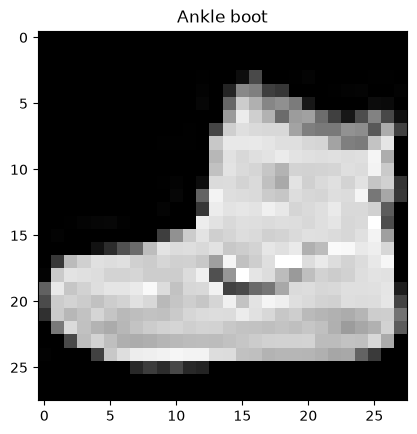

In [9]:
plt.imshow(image.squeeze(),cmap= "gray")
plt.title(class_names[label])

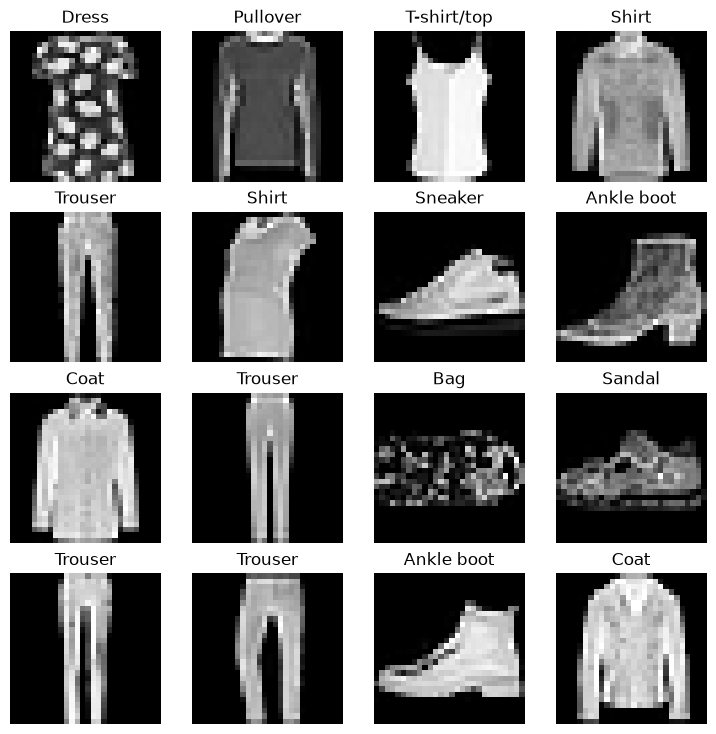

In [10]:
fig = plt.figure(figsize= (9,9))
for i in range(1,17):

    random_idx = torch.randint(0,len(train_data),size = [1]).item()

    img,label = train_data[random_idx]

    fig.add_subplot(4, 4, i)
    plt.imshow(img.squeeze(),cmap = "gray")
    plt.title(class_names[label])
    plt.axis(False);



In [11]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader = DataLoader(train_data,
                              batch_size= BATCH_SIZE,
                              shuffle = True)

test_dataloader = DataLoader(test_data,
                            batch_size=BATCH_SIZE,
                            shuffle=False)



In [12]:
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

In [13]:
flatten_model = nn.Flatten()

In [27]:
class FashionMNISTModel(nn.Module):
    def __init__(self,input_shape: int,output_shape: int,hidden_units = 8):
        super().__init__()

        self.Linear_Layer_Stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape,out_features=hidden_units),
            nn.Linear(in_features=hidden_units,out_features=hidden_units),
            nn.Linear(in_features=hidden_units,out_features=output_shape),
        )

    def forward(self,x):
        return self.Linear_Layer_Stack(x)

In [28]:
torch.manual_seed(42)

model_0 = FashionMNISTModel(input_shape=784,output_shape=len(class_names),hidden_units= 10)

model_0.to(device)

next(model_0.parameters()).device

device(type='cuda', index=0)

In [29]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(params = model_0.parameters(),
                            lr = 0.01)


In [30]:
from timeit import default_timer as timer 


In [31]:
def print_train_time(start: float, end : float ,device : torch.device = None):
    total_time = end - start
    print(f"Time taken is {total_time} in sec")
    return total_time

In [32]:
from tqdm.auto import tqdm 


In [33]:
from torchmetrics import Accuracy

acc_fn = Accuracy(task = "multiclass",num_classes= len(class_names)).to(device)

In [34]:
torch.manual_seed(42)

epochs = 100

train_time_start = timer()

for _ in range(epochs):
    
    train_loss = 0

    for batch,(X,y) in enumerate(train_dataloader):

        X = X.to(device)
        y = y.to(device)
        model_0.train()

        y_pred = model_0(X)

        loss = loss_fn(y_pred,y)

        train_loss += loss

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        if batch % 400 == 0 :
            print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples")

    train_loss /=len(train_dataloader)

    test_loss = 0
    test_acc = 0

    model_0.eval()
    with torch.inference_mode():
        for X, y in test_dataloader:
            
            X = X.to(device)
            y = y.to(device)

            y_preds = model_0(X)

            test_loss += loss_fn(y_preds,y)

            test_acc +=  acc_fn(y,y_preds.argmax(dim = 1))

        test_loss /= len(test_dataloader)

        test_acc /= len(test_dataloader)

        print(f"Train Loss = {loss} | Test Loss = {test_loss} | Test Acc = {test_acc}")


train_time_end = timer()



total_train_time_model_0 = print_train_time(start=train_time_start, 
                                           end=train_time_end,
                                           device=str(next(model_0.parameters()).device))



Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train Loss = 0.4181002974510193 | Test Loss = 0.6601061820983887 | Test Acc = 0.757388174533844
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train Loss = 0.6094250082969666 | Test Loss = 0.572321355342865 | Test Acc = 0.7982228398323059
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train Loss = 0.35597795248031616 | Test Loss = 0.5447394251823425 | Test Acc = 0.8086062073707581
Looked at 0/60000 samples
Looked at 12800/60000 samples
Looked at 25600/60000 samples
Looked at 38400/60000 samples
Looked at 51200/60000 samples
Train Loss = 0.5986714363098145 | Test Loss = 0.519148051738739 | Test Acc = 0.8188897371292114
Looked at 0/60000 samples
Look

In [35]:
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents = True,exist_ok = True)

MODEL_NAME = "FMNIST_Linear_Model"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

torch.save(obj = model_0.state_dict(),f =MODEL_SAVE_PATH)